In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/ToyotaCorolla.csv', index_col='Id')
pd.set_option('display.max_columns', None)
df.head()

,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airbag_1,Airbag_2,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,0,1,3,1,1,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,Silver,0,2000,3,4,5,210,1165,0,1,3,1,1,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0,0
3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,Blue,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,Black,0,2000,3,4,5,210,1165,1,1,3,1,1,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0
5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,Black,0,2000,3,4,5,210,1170,1,1,3,1,1,1,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0


In [ ]:
print(df.info)

<bound method DataFrame.info of                                                   Model  Price  Age_08_04  \
Id                                                                          
1         TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500         23   
2         TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750         23   
3         TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950         24   
4         TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  14950         26   
5           TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors  13750         30   
...                                                 ...    ...        ...   
1438         TOYOTA Corolla 1.3 16V HATCHB G6 2/3-Doors   7500         69   
1439  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...  10845         72   
1440  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...   8500         71   
1441  TOYOTA Corolla 1.3 16V HATCHB LINEA TERRA 2/3-...   7250         70   
1442        TOYOTA Corolla 1.6 LB LINEA TERR

In [ ]:
print(df.columns)

Index(['Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM',
       'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'CC', 'Doors',
       'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee',
       'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2',
       'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player',
       'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio',
       'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim',
       'Radio_cassette', 'Parking_Assistant', 'Tow_Bar'],
      dtype='object')


In [ ]:
print(df.isna().sum())

Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64


In [ ]:
print(df.duplicated().sum())

1


In [ ]:
print(df['Fuel_Type'].unique())
print(df['Color'].unique())

['Diesel' 'Petrol' 'CNG']
['Blue' 'Silver' 'Black' 'White' 'Grey' 'Red' 'Green' 'Yellow' 'Violet'
 'Beige']


In [ ]:
df['Airbags']=df['Airbag_1'].apply(func=int)+df['Airbag_2'].apply(func=int)
colors=pd.get_dummies(df['Color'])
fuel_type=pd.get_dummies(df['Fuel_Type'])
df=pd.concat([df,colors,fuel_type],axis=1)
df.drop(['Airbag_1', 'Airbag_2', 'Color', 'Fuel_Type', 'Mfg_Month', 'Mfg_Year'], axis=1, inplace=True)
bin_feat=['Diesel', 'Petrol', 'CNG', 'Blue', 'Silver',  'Black',  'White',   'Grey',    'Red',  'Green', 'Yellow', 'Violet',  'Beige']
df[bin_feat]=df[bin_feat].astype(int)
print(df.columns)
df.head()

Index(['Model', 'Price', 'Age_08_04', 'KM', 'HP', 'Met_Color', 'Automatic',
       'CC', 'Doors', 'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight',
       'Mfr_Guarantee', 'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airco',
       'Automatic_airco', 'Boardcomputer', 'CD_Player', 'Central_Lock',
       'Powered_Windows', 'Power_Steering', 'Radio', 'Mistlamps',
       'Sport_Model', 'Backseat_Divider', 'Metallic_Rim', 'Radio_cassette',
       'Parking_Assistant', 'Tow_Bar', 'Airbags', 'Beige', 'Black', 'Blue',
       'Green', 'Grey', 'Red', 'Silver', 'Violet', 'White', 'Yellow', 'CNG',
       'Diesel', 'Petrol'],
      dtype='object')


,Model,Price,Age_08_04,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Airbags,Beige,Black,Blue,Green,Grey,Red,Silver,Violet,White,Yellow,CNG,Diesel,Petrol
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,46986,90,1,0,2000,3,4,5,210,1165,0,1,3,1,0,0,1,0,1,1,1,0,0,0,1,0,0,0,0,2,0,0,1,0,0,0,0,0,0,0,0,1,0
2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,72937,90,1,0,2000,3,4,5,210,1165,0,1,3,1,1,0,1,1,1,0,1,0,0,0,1,0,0,0,0,2,0,0,0,0,0,0,1,0,0,0,0,1,0
3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,41711,90,1,0,2000,3,4,5,210,1165,1,1,3,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,2,0,0,1,0,0,0,0,0,0,0,0,1,0
4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,48000,90,0,0,2000,3,4,5,210,1165,1,1,3,1,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,1,0
5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,38500,90,0,0,2000,3,4,5,210,1170,1,1,3,1,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,1,0


In [ ]:
df_num=df.select_dtypes(include='number')
df_num.corr()

,Price,Age_08_04,KM,HP,Met_Color,Automatic,CC,Doors,Cylinders,Gears,Quarterly_Tax,Weight,Mfr_Guarantee,BOVAG_Guarantee,Guarantee_Period,ABS,Airco,Automatic_airco,Boardcomputer,CD_Player,Central_Lock,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar,Airbags,Beige,Black,Blue,Green,Grey,Red,Silver,Violet,White,Yellow,CNG,Diesel,Petrol
Price,1.000000,-0.876590,-0.569960,0.314990,0.108905,0.033081,0.126389,0.185326,NaN,0.063104,0.219197,0.581198,0.197802,0.028133,0.146627,0.306138,0.429259,0.588262,0.601292,0.481374,0.343458,0.356518,0.064275,-0.041887,0.222083,0.164121,0.102569,0.108564,-0.043179,0.044375,-0.172369,0.244354,-0.022684,0.034896,0.014431,-0.104963,0.169947,-0.103803,0.028562,-0.016848,-0.103360,0.022726,-0.039536,0.054084,-0.038516
Age_08_04,-0.876590,1.000000,0.505672,-0.156622,-0.108150,0.031717,-0.098084,-0.148359,NaN,-0.005364,-0.198431,-0.470253,-0.164658,0.006865,-0.152563,-0.412887,-0.403600,-0.426259,-0.719449,-0.510895,-0.279631,-0.283856,-0.069192,0.013791,-0.126895,-0.110988,-0.116751,-0.040045,0.012857,-0.048172,0.188720,-0.316999,0.023098,-0.019399,-0.032955,0.103530,-0.137660,0.098365,-0.028550,0.017916,0.050933,-0.040883,0.002389,-0.097740,0.092611
KM,-0.569960,0.505672,1.000000,-0.333538,-0.080503,-0.081854,0.102683,-0.036197,NaN,0.015023,0.278165,-0.028598,-0.212851,0.001438,-0.138942,-0.177203,-0.133057,-0.258221,-0.353862,-0.266826,-0.125177,-0.156242,0.007397,0.013661,-0.074327,-0.044784,-0.045658,-0.013599,0.015770,-0.064318,0.084153,-0.125576,-0.006720,0.039012,-0.003840,-0.017439,-0.112194,0.052190,0.006113,0.018810,0.130403,-0.037995,0.144016,0.403060,-0.433160
HP,0.314990,-0.156622,-0.333538,1.000000,0.058712,0.013144,0.035856,0.092424,NaN,0.209477,-0.298432,0.089614,0.140026,0.022701,0.076163,0.057832,0.241134,0.244957,0.129715,0.102300,0.250122,0.265593,0.048850,0.020998,0.210571,-0.006027,0.010908,0.206784,0.019919,0.029990,0.068271,0.023306,0.025963,-0.002040,-0.027949,0.021242,0.021349,0.011700,0.014300,-0.012359,-0.093928,-0.000516,0.062109,-0.533453,0.489110
Met_Color,0.108905,-0.108150,-0.080503,0.058712,1.000000,-0.019335,0.031812,0.085243,NaN,0.018601,0.011326,0.057929,0.154850,0.010783,0.009295,0.022298,0.114190,0.027977,0.089886,0.198220,0.153307,0.145147,0.086544,0.072756,0.023821,0.003779,0.037741,0.053829,0.071530,0.036691,0.148536,0.065414,0.031764,0.061789,0.044972,0.084797,0.072634,-0.261828,0.104902,0.036691,-0.203738,0.031764,0.021009,-0.012420,0.004872
Automatic,0.033081,0.031717,-0.081854,0.013144,-0.019335,1.000000,0.066740,-0.027654,NaN,-0.098555,-0.055371,0.057249,0.026194,0.023393,-0.002256,-0.016128,-0.028353,0.059057,-0.037069,-0.010967,-0.002502,-0.005864,-0.004469,-0.014600,0.003077,0.013175,-0.018876,-0.078095,-0.014150,0.159985,0.018786,-0.002843,-0.011114,-0.041491,-0.005847,0.056846,0.001725,-0.026799,0.045772,-0.012837,-0.036079,-0.011114,0.001486,-0.084490,0.080249
CC,0.126389,-0.098084,0.102683,0.035856,0.031812,0.066740,1.000000,0.079903,NaN,0.014629,0.306996,0.335637,-0.057407,-0.081725,-0.017683,0.037806,0.119888,0.162669,0.009312,0.057787,0.072634,0.055299,0.032933,-0.000361,0.017326,-0.035195,-0.055711,0.003236,-0.000470,0.002883,0.002725,0.028610,0.002496,-0.007964,0.029421,-0.010579,-0.009867,-0.008865,-0.001351,-0.015804,0.027304,-0.011884,0.005941,0.327723,-0.315170
Doors,0.185326,-0.148359,-0.036197,0.092424,0.085243,-0.027654,0.079903,1.000000,NaN,-0.160141,0.109363,0.302618,0.037689,-0.014311,0.053654,0.063733,0.170544,0.054809,0.089606,0.094653,0.132092,0.107626,0.059792,-0.008318,0.064705,-0.129881,-0.022542,-0.039555,-0.008265,0.025893,0.102292,0.036109,-0.033636,-0.099880,-0.044962,0.060186,0.059174,-0.000541,0.028644,0.012019,-0.010245,0.014409,0.009680,0.025495,-0.027589
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ge

<Axes: xlabel='Price', ylabel='Count'>

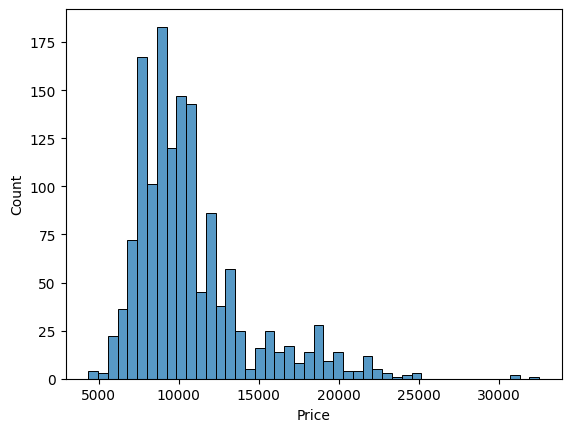

In [ ]:
sns.histplot(df['Price'])

<Axes: >

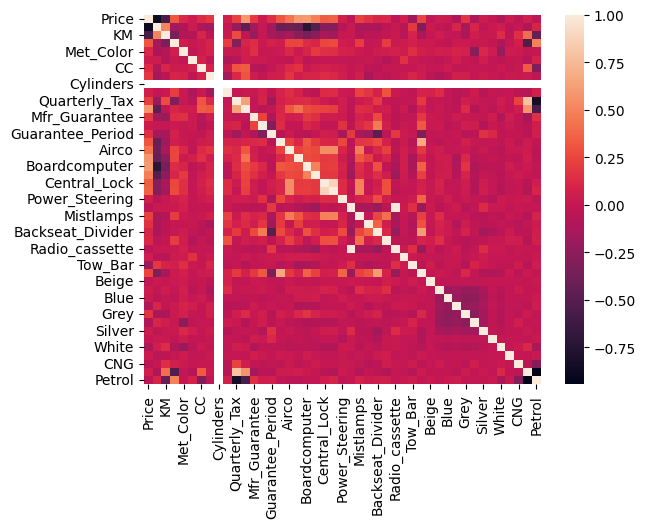

In [ ]:
sns.heatmap(df_num.corr())



# 2.   EDA и предобработка
  предобработка: вывел все колонки, поправил индекс, посмотрел информацию по датасету, посмотрел на пропущенные значения (их нет), подготовил датасет из числовых признаков



# 3.   Обработка признаков
  я использовал OHE чтобы модель могла работать с классификационными признаками (цвет авто и топливо), убрал mfg_month/year авто, т.к. уже есть один признак - возраст



In [ ]:
from sklearn.model_selection import train_test_split
X=df_num.drop(['Price'],axis=1)
y=df['Price']
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Разделение выборки
  сначала я отделил искомый признак - Price
  затем разделил выборку 80/20 (train/test) и установил фиксированное ее разделение через сид 42

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import GridSearchCV

params={'alpha':np.linspace(10,30,120)}

In [ ]:
lr=LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
#ridge=Ridge()
#grid_ridge=GridSearchCV(ridge, params, scoring='r2', cv=120)
grid_ridge=Ridge(alpha=12.85)
grid_ridge.fit(X_train, y_train)
#12.85

Ridge(alpha=12.85)

In [ ]:
#lasso=Lasso()
#grid_lasso=GridSearchCV(lasso, params, scoring='r2', cv=120)
grid_lasso=Lasso(alpha=12.7)
grid_lasso.fit(X_train, y_train)
#12.7

Lasso(alpha=12.7)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error
y_pred_lr=lr.predict(X_test)
y_pred_ridge=grid_ridge.predict(X_test)
y_pred_lasso=grid_lasso.predict(X_test)

res_lin=pd.Series([r2_score(y_test,y_pred_lr),r2_score(y_test,y_pred_ridge),r2_score(y_test,y_pred_lasso)],name='R2', index=['LR','Ridge','Lasso'])

res_lin

,R2
LR,0.882772
Ridge,0.885215
Lasso,0.886732


In [ ]:
#lasso_params={'alpha':np.linspace(0,10,20)}
#new_lasso=GridSearchCV(lasso, lasso_params, scoring='neg_mean_absolute_percentage_error', cv=20 )
new_lasso=Lasso(alpha=3.68)
new_lasso.fit(X_train,y_train)
#3.68

Lasso(alpha=3.68)

In [ ]:
y_pred_new_lasso=new_lasso.predict(X_test)
print(mean_absolute_percentage_error(y_test,y_pred_new_lasso))

0.08463094675258473


# 5. Обучение модели
  я проделал следующий алгоритм:
  1. взял модели LR, Ridge, Lasso и для последних двух нашел наилучший гиперпараметр согласно R2
  2. сравнил все эти модели с лучшими гиперпараметрами по метрике R2
  3. получил лучшую модель (Lasso) и тренировал ее на более подходящей для датасета метрике MAPE

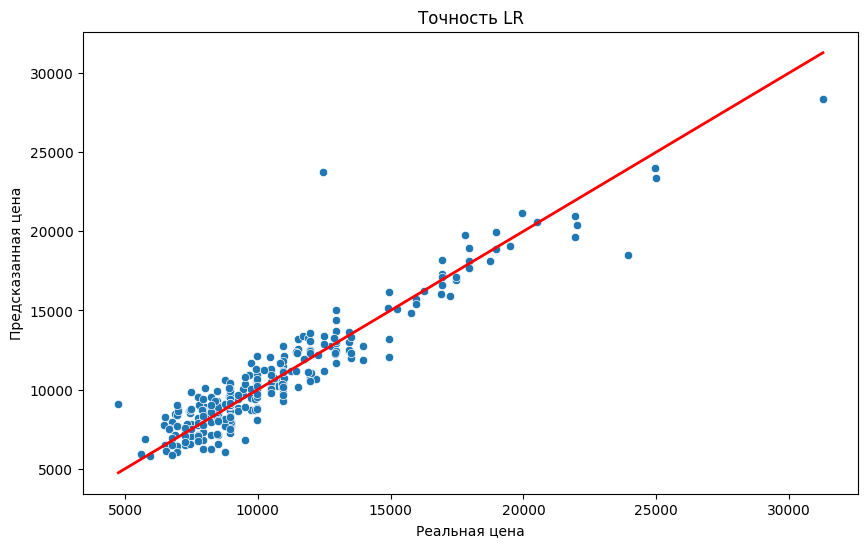

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red',linewidth=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Точность LR')
plt.show()

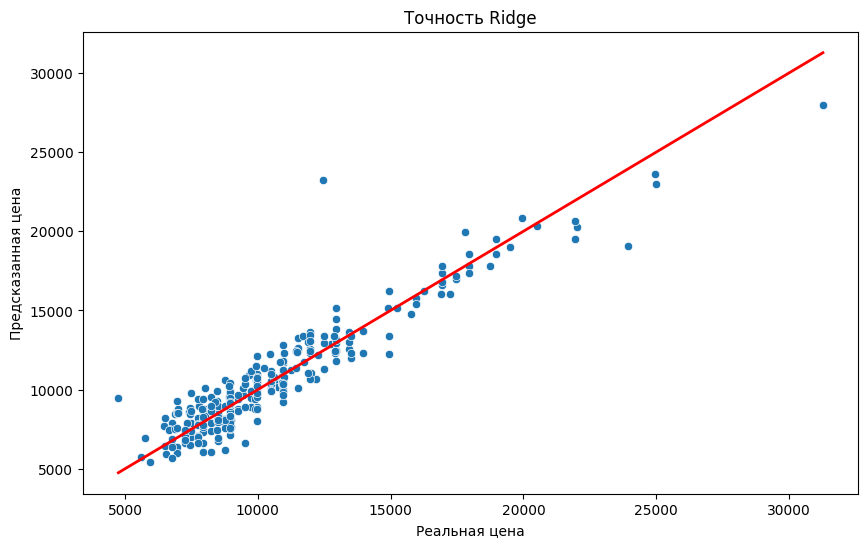

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_ridge)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red',linewidth=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Точность Ridge')
plt.show()

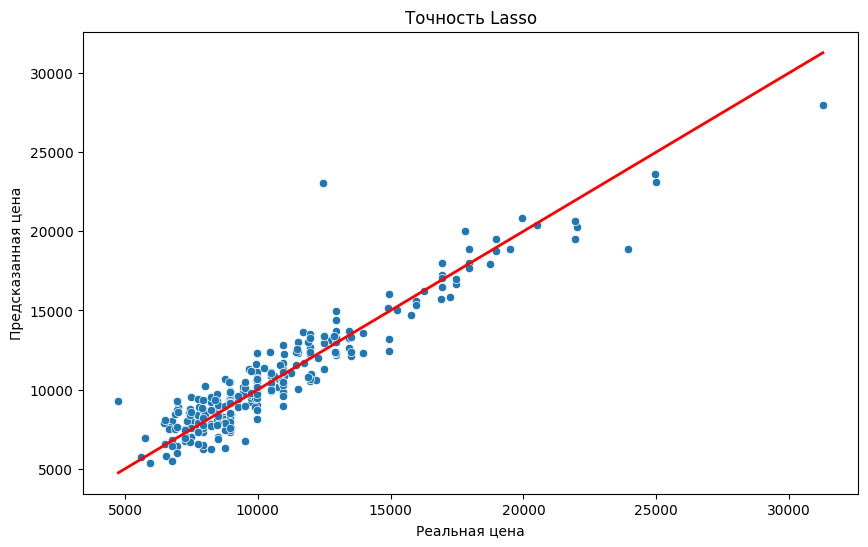

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lasso)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red',linewidth=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title('Точность Lasso')
plt.show()

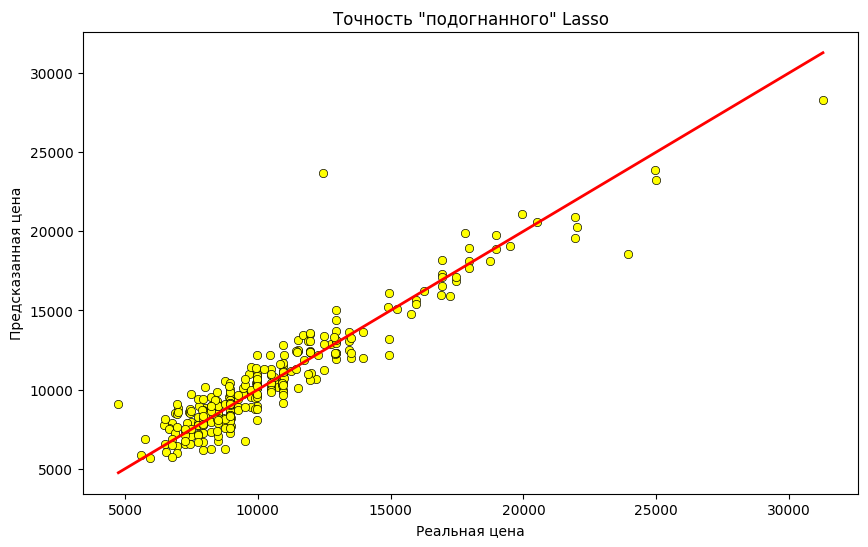

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_new_lasso, color='yellow', edgecolor='black')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', label='Идеальная модель', linewidth=2)
plt.xlabel('Реальная цена')
plt.ylabel('Предсказанная цена')
plt.title(f'Точность \"подогнанного\" Lasso')
plt.show()